# A matemática do ruído em DDPM — animações com Manim

Este notebook mostra como os coeficientes de um DDPM controlam a transformação de uma imagem MNIST em ruído (**forward process**) e como o modelo treinado remove esse ruído (**backward process**). As animações usam dados reais das fórmulas em cada timestep; exibimos checkpoints representativos para manter o vídeo legível.

## 1. Preparação

No Ubuntu, o Manim precisa das bibliotecas nativas abaixo uma única vez:

```bash
sudo apt install libcairo2-dev libpango1.0-dev
uv sync
```

O notebook reutiliza o checkpoint criado por `ddpm_ddim_mnist.ipynb`. Vídeos e arquivos temporários ficam em `seminar_1/data/mnist/manim`.

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Video
from manim import *
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 42
T = 1_000
FORWARD_STEPS = [0, 100, 250, 500, 750, 999]
BACKWARD_STEPS = [999, 750, 500, 250, 0]
MANIM_QUALITY = "medium_quality"
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ROOT = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
MNIST_DIR = ROOT / "seminar_1" / "data" / "mnist"
MANIM_DIR = MNIST_DIR / "manim"
MANIM_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS = [MNIST_DIR / "models" / "ddpm_mnist_metrics.pt", MNIST_DIR / "models" / "ddpm_mnist.pt"]
CHECKPOINT = next((path for path in CHECKPOINTS if path.exists()), None)
assert CHECKPOINT is not None, "Execute primeiro ddpm_ddim_mnist.ipynb para criar o checkpoint."
print(f"device={DEVICE}; checkpoint={CHECKPOINT.name}; saída={MANIM_DIR}")

/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


device=cpu; checkpoint=ddpm_mnist_metrics.pt; saída=/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_1/data/mnist/manim


## 2. Schedule e processo forward

Em um passo, adicionamos uma pequena quantidade de ruído gaussiano:

$$q(x_t\mid x_{t-1})=\mathcal N(\sqrt{\alpha_t}x_{t-1},\beta_t I),\qquad \alpha_t=1-\beta_t.$$

Como o processo é gaussiano, podemos ir diretamente de $x_0$ para qualquer $x_t$:

$$x_t=\underbrace{\sqrt{\bar\alpha_t}}_{\text{sinal}}x_0+\underbrace{\sqrt{1-\bar\alpha_t}}_{\text{ruído}}\epsilon,\qquad \bar\alpha_t=\prod_{s=1}^{t}\alpha_s.$$

Usaremos o mesmo $\epsilon$ em todos os checkpoints para enxergar somente o efeito dos coeficientes.

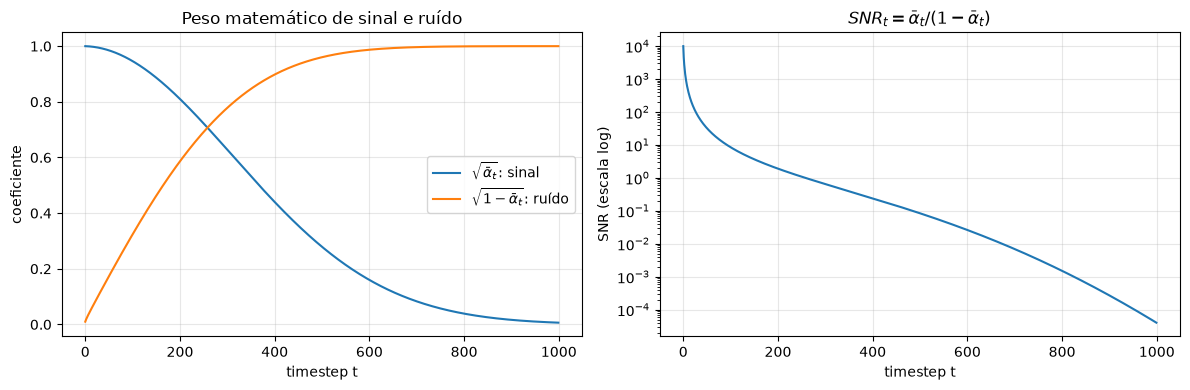

In [2]:
betas = torch.linspace(1e-4, 2e-2, T, device=DEVICE)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars_previous = F.pad(alpha_bars[:-1], (1, 0), value=1.0)
posterior_variance = betas * (1 - alpha_bars_previous) / (1 - alpha_bars)
signal_coefficients = alpha_bars.sqrt()
noise_coefficients = (1 - alpha_bars).sqrt()
snr = alpha_bars / (1 - alpha_bars)

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
mnist = datasets.MNIST(MNIST_DIR / "source", train=False, download=False, transform=transform)
x0 = mnist[0][0].unsqueeze(0).to(DEVICE)
fixed_noise = torch.randn_like(x0, generator=torch.Generator(device=DEVICE).manual_seed(SEED))
forward_frames = {
    step: signal_coefficients[step] * x0 + noise_coefficients[step] * fixed_noise
    for step in FORWARD_STEPS
}
assert forward_frames[0].shape == x0.shape and signal_coefficients[-1] < 0.01

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(signal_coefficients.cpu(), label=r"$\sqrt{\bar\alpha_t}$: sinal")
axes[0].plot(noise_coefficients.cpu(), label=r"$\sqrt{1-\bar\alpha_t}$: ruído")
axes[0].set(xlabel="timestep t", ylabel="coeficiente", title="Peso matemático de sinal e ruído")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].semilogy(snr.cpu())
axes[1].set(xlabel="timestep t", ylabel="SNR (escala log)", title=r"$SNR_t=\bar\alpha_t/(1-\bar\alpha_t)$")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

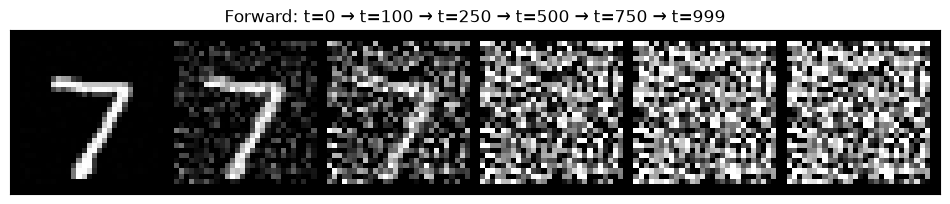

t=000: sinal=0.9999, ruído=0.0100, SNR=9997.340820
t=100: sinal=0.9461, ruído=0.3238, SNR=8.536649
t=250: sinal=0.7221, ruído=0.6918, SNR=1.089528
t=500: sinal=0.2789, ruído=0.9603, SNR=0.084360
t=750: sinal=0.0574, ruído=0.9983, SNR=0.003311
t=999: sinal=0.0064, ruído=1.0000, SNR=0.000040


In [3]:
grid = make_grid(torch.cat([forward_frames[step] for step in FORWARD_STEPS]).cpu().clamp(-1, 1), nrow=len(FORWARD_STEPS), normalize=True, value_range=(-1, 1))
plt.figure(figsize=(12, 2.5))
plt.imshow(grid.permute(1, 2, 0))
plt.xticks([])
plt.yticks([])
plt.title("Forward: " + " → ".join(f"t={step}" for step in FORWARD_STEPS))
plt.show()

for step in FORWARD_STEPS:
    print(f"t={step:03d}: sinal={signal_coefficients[step]:.4f}, ruído={noise_coefficients[step]:.4f}, SNR={snr[step]:.6f}")

## 3. Animação Manim do forward

A imagem animada é o resultado numérico da fórmula mostrada na tela. Quando $\sqrt{\bar\alpha_t}$ cai, os pixels de $x_0$ deixam de influenciar $x_t$; simultaneamente, o coeficiente do ruído se aproxima de 1.

In [4]:
def tensor_to_rgb(tensor):
    gray = ((tensor.squeeze().detach().cpu().clamp(-1, 1) + 1) * 127.5).numpy().astype(np.uint8)
    return np.repeat(gray[:, :, None], 3, axis=2)

def image_mobject(tensor):
    return ImageMobject(tensor_to_rgb(tensor)).set_height(3.6).shift(LEFT * 3 + DOWN * 0.5)

def forward_values(step):
    return VGroup(
        MathTex(rf"t={step}"),
        MathTex(rf"\sqrt{{\bar\alpha_t}}={signal_coefficients[step].item():.4f}", color=BLUE),
        MathTex(rf"\sqrt{{1-\bar\alpha_t}}={noise_coefficients[step].item():.4f}", color=ORANGE),
        MathTex(rf"\mathrm{{SNR}}_t={snr[step].item():.4f}", color=GREEN),
    ).arrange(DOWN, aligned_edge=LEFT, buff=0.25).scale(0.72).shift(RIGHT * 3 + DOWN * 0.5)

class ForwardDiffusionScene(Scene):
    def construct(self):
        self.camera.background_color = "#0f172a"
        title = Text("Forward process: imagem → ruído", font_size=34).to_edge(UP)
        formula = MathTex(r"x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon").scale(0.78).next_to(title, DOWN)
        image = image_mobject(forward_frames[FORWARD_STEPS[0]])
        frame = SurroundingRectangle(image, color=WHITE, buff=0.08)
        values = forward_values(FORWARD_STEPS[0])
        arrow = Arrow(image.get_right(), values.get_left(), color=YELLOW, buff=0.3)
        self.play(Write(title), Write(formula))
        self.play(FadeIn(image), Create(frame), GrowArrow(arrow), FadeIn(values))
        for step in FORWARD_STEPS[1:]:
            next_image = image_mobject(forward_frames[step])
            next_values = forward_values(step)
            self.play(FadeTransform(image, next_image), Transform(values, next_values), run_time=1.2)
            image = next_image
        self.wait(1)

def render_scene(scene_type):
    with tempconfig({"quality": MANIM_QUALITY, "media_dir": str(MANIM_DIR), "disable_caching": True, "preview": False}):
        scene = scene_type()
        scene.render()
        return Path(scene.renderer.file_writer.movie_file_path)

forward_video = render_scene(ForwardDiffusionScene)
Video(str(forward_video), embed=True)

[08/10/26 16:45:44] INFO     Writing \special{dvisvgm:raw <g                                ]8;id=8061250;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py\tex_file_writing.py]8;;\:]8;id=8061251;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py#110\110]8;;\
                             id='unique000'>}x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_                        
                             t}\epsilon\special{dvisvgm:raw </g>} to                                               
                             /home/matheus/Documentos/mestrado/repositories/matheus-983-tp5                        
                             58/seminar_1/data/mnist/manim/Tex/fce50abe10e231cf.tex                                

/tmp/ipykernel_152740/752356389.py:6: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().
  return ImageMobject(tensor_to_rgb(tensor)).set_height(3.6).shift(LEFT * 3 + DOWN * 0.5)


[08/10/26 16:45:46] INFO     Writing \special{dvisvgm:raw <g                                ]8;id=8061256;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py\tex_file_writing.py]8;;\:]8;id=8061257;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py#110\110]8;;\
                             id='unique000'>}t=0\special{dvisvgm:raw </g>} to                                      
                             /home/matheus/Documentos/mestrado/repositories/matheus-983-tp5                        
                             58/seminar_1/data/mnist/manim/Tex/8afd612618c7979b.tex                                

                    INFO     Writing \special{dvisvgm:raw <g                                ]8;id=8061262;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py\tex_file_writing.py]8;;\:]8;id=8061263;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py#110\110]8;;\
                             id='unique000'>}\sqrt{\bar\alpha_t}=0.9999\special{dvisvgm:raw                        
                             </g>} to                                                                              
                             /home/matheus/Documentos/mestrado/repositories/matheus-983-tp5                        
                             58/seminar_1/data/mnist/manim/Tex/417c39c79d724696.tex                                

[08/10/26 16:45:47] INFO     Writing \special{dvisvgm:raw <g                                ]8;id=8061268;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py\tex_file_writing.py]8;;\:]8;id=8061269;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py#110\110]8;;\
                             id='unique000'>}\sqrt{1-\bar\alpha_t}=0.0100\special{dvisvgm:r                        
                             aw </g>} to                                                                           
                             /home/matheus/Documentos/mestrado/repositories/matheus-983-tp5                        
                             58/seminar_1/data/mnist/manim/Tex/1fd1daad1b39230b.tex                                

...

                    INFO     Caching disabled.                                                 ]8;id=8061488;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=8061489;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

                    INFO     Animation 7 : Partial movie file written in                   ]8;id=8061494;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=8061495;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/mnist/manim/videos/720p30/partial_movie_f                         
                             iles/ForwardDiffusionScene/uncached_00007.mp4'                                        

                    INFO     Combining to Movie file.                                      ]8;id=8061501;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=8061502;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#753\753]8;;\

                    INFO                                                                   ]8;id=8061508;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=8061509;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#904\904]8;;\
                             File ready at                                                                         
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/mnist/manim/videos/720p30/ForwardDiffusio                         
                             nScene.mp4'                                                                           
                                                                                                                   

                    INFO     Rendered ForwardDiffusionScene                                            ]8;id=8061516;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=8061517;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py#278\278]8;;\
                             Played 8 animations                                                                   

## 4. Matemática do processo backward

O modelo aprende a estimar o ruído presente em $x_t$, denotado por $\epsilon_\theta(x_t,t)$. Essa previsão entra na média da distribuição reversa:

$$\mu_\theta(x_t,t)=\frac{1}{\sqrt{\alpha_t}}\left(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta(x_t,t)\right).$$

Então cada passo reverso é:

$$x_{t-1}=\mu_\theta(x_t,t)+\sqrt{\tilde\beta_t}z,\qquad z\sim\mathcal N(0,I),$$

onde $\tilde\beta_t=\beta_t(1-\bar\alpha_{t-1})/(1-\bar\alpha_t)$. O primeiro termo remove o ruído previsto; o segundo mantém a amostragem probabilística.

In [5]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, size=32):
        super().__init__()
        half = size // 2
        self.register_buffer("frequencies", torch.exp(-math.log(10_000) * torch.arange(half) / (half - 1)))

    def forward(self, timesteps):
        angles = timesteps[:, None].float() * self.frequencies[None]
        return torch.cat((angles.sin(), angles.cos()), dim=1)

class TinyDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.time = nn.Sequential(SinusoidalTimeEmbedding(), nn.Linear(32, 64), nn.SiLU())
        self.time1, self.time2, self.time3 = nn.Linear(64, 32), nn.Linear(64, 64), nn.Linear(64, 64)
        self.down1 = nn.Conv2d(1, 32, 3, padding=1)
        self.down2 = nn.Conv2d(32, 64, 4, stride=2, padding=1)
        self.down3 = nn.Conv2d(64, 64, 4, stride=2, padding=1)
        self.up1 = nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1)
        self.up2 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.output = nn.Conv2d(32, 1, 3, padding=1)
        self.norm1, self.norm5 = nn.GroupNorm(8, 32), nn.GroupNorm(8, 32)
        self.norm2, self.norm3, self.norm4 = nn.GroupNorm(8, 64), nn.GroupNorm(8, 64), nn.GroupNorm(8, 64)

    def forward(self, x, timesteps):
        embedding = self.time(timesteps)
        h1 = F.silu(self.norm1(self.down1(x) + self.time1(embedding)[:, :, None, None]))
        h2 = F.silu(self.norm2(self.down2(h1) + self.time2(embedding)[:, :, None, None]))
        h3 = F.silu(self.norm3(self.down3(h2) + self.time3(embedding)[:, :, None, None]))
        h = F.silu(self.norm4(self.up1(h3) + h2))
        h = F.silu(self.norm5(self.up2(h) + h1))
        return self.output(h)

model = TinyDenoiser().to(DEVICE)
checkpoint = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint["model"] if "model" in checkpoint else checkpoint)
model.eval()
assert model(torch.zeros(1, 1, 28, 28, device=DEVICE), torch.tensor([999], device=DEVICE)).shape == (1, 1, 28, 28)

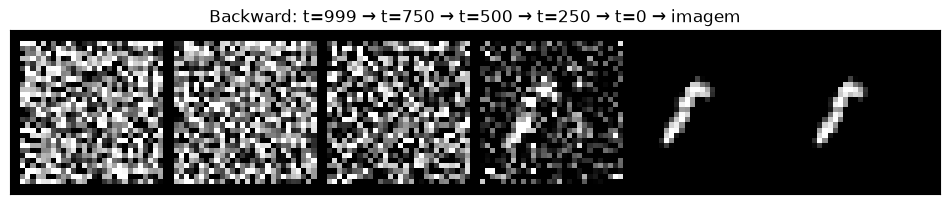

In [6]:
@torch.inference_mode()
def reverse_process():
    torch.manual_seed(SEED)
    x = torch.randn(1, 1, 28, 28, device=DEVICE)
    frames = {}
    for step in reversed(range(T)):
        if step in BACKWARD_STEPS:
            frames[step] = x.detach().cpu()
        timesteps = torch.full((1,), step, device=DEVICE, dtype=torch.long)
        predicted_noise = model(x, timesteps)
        mean = (x - betas[step] / torch.sqrt(1 - alpha_bars[step]) * predicted_noise) / torch.sqrt(alphas[step])
        x = mean + posterior_variance[step].sqrt() * torch.randn_like(x) if step > 0 else mean
    frames["final"] = x.detach().cpu().clamp(-1, 1)
    return frames

backward_frames = reverse_process()
backward_order = BACKWARD_STEPS + ["final"]
grid = make_grid(torch.cat([backward_frames[step] for step in backward_order]), nrow=len(backward_order), normalize=True, value_range=(-1, 1))
plt.figure(figsize=(12, 2.5))
plt.imshow(grid.permute(1, 2, 0))
plt.xticks([])
plt.yticks([])
plt.title("Backward: " + " → ".join("imagem" if step == "final" else f"t={step}" for step in backward_order))
plt.show()

## 5. Animação Manim do backward

A rede é avaliada em todos os 1.000 timesteps. A animação mostra apenas cinco estados intermediários e o resultado final; portanto, nenhum passo matemático é pulado durante a geração.

In [7]:
def backward_values(step):
    if step == "final":
        return VGroup(Text("imagem gerada", font_size=30), MathTex(r"x_0\sim p_\theta(x_0)", color=GREEN)).arrange(DOWN, buff=0.3).shift(RIGHT * 3 + DOWN * 0.5)
    removal = (betas[step] / torch.sqrt(1 - alpha_bars[step])).item()
    stochasticity = posterior_variance[step].sqrt().item()
    return VGroup(
        MathTex(rf"t={step}"),
        MathTex(rf"\frac{{\beta_t}}{{\sqrt{{1-\bar\alpha_t}}}}={removal:.5f}", color=BLUE),
        MathTex(rf"\sqrt{{\tilde\beta_t}}={stochasticity:.5f}", color=ORANGE),
    ).arrange(DOWN, aligned_edge=LEFT, buff=0.3).scale(0.75).shift(RIGHT * 3 + DOWN * 0.5)

class BackwardDiffusionScene(Scene):
    def construct(self):
        self.camera.background_color = "#0f172a"
        title = Text("Backward process: ruído → imagem", font_size=34).to_edge(UP)
        formula = MathTex(r"x_{t-1}=\mu_\theta(x_t,t)+\sqrt{\tilde\beta_t}z").scale(0.82).next_to(title, DOWN)
        image = image_mobject(backward_frames[backward_order[0]])
        frame = SurroundingRectangle(image, color=WHITE, buff=0.08)
        values = backward_values(backward_order[0])
        arrow = Arrow(values.get_left(), image.get_right(), color=YELLOW, buff=0.3)
        self.play(Write(title), Write(formula))
        self.play(FadeIn(image), Create(frame), GrowArrow(arrow), FadeIn(values))
        for step in backward_order[1:]:
            next_image = image_mobject(backward_frames[step])
            next_values = backward_values(step)
            self.play(FadeTransform(image, next_image), Transform(values, next_values), run_time=1.2)
            image = next_image
        self.wait(1)

backward_video = render_scene(BackwardDiffusionScene)
Video(str(backward_video), embed=True)

[08/10/26 16:46:09] INFO     Writing \special{dvisvgm:raw <g                                ]8;id=8061522;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py\tex_file_writing.py]8;;\:]8;id=8061523;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py#110\110]8;;\
                             id='unique000'>}x_{t-1}=\mu_\theta(x_t,t)+\sqrt{\tilde\beta_t}                        
                             z\special{dvisvgm:raw </g>} to                                                        
                             /home/matheus/Documentos/mestrado/repositories/matheus-983-tp5                        
                             58/seminar_1/data/mnist/manim/Tex/aee8e6e1f2b964de.tex                                

/tmp/ipykernel_152740/752356389.py:6: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().
  return ImageMobject(tensor_to_rgb(tensor)).set_height(3.6).shift(LEFT * 3 + DOWN * 0.5)


[08/10/26 16:46:10] INFO     Writing \special{dvisvgm:raw <g                                ]8;id=8061528;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py\tex_file_writing.py]8;;\:]8;id=8061529;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py#110\110]8;;\
                             id='unique000'>}\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}=0.02000\                        
                             special{dvisvgm:raw </g>} to                                                          
                             /home/matheus/Documentos/mestrado/repositories/matheus-983-tp5                        
                             58/seminar_1/data/mnist/manim/Tex/fbb82d31da1dab60.tex                                

                    INFO     Writing \special{dvisvgm:raw <g                                ]8;id=8061534;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py\tex_file_writing.py]8;;\:]8;id=8061535;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/utils/tex_file_writing.py#110\110]8;;\
                             id='unique000'>}\sqrt{\tilde\beta_t}=0.14142\special{dvisvgm:r                        
                             aw </g>} to                                                                           
                             /home/matheus/Documentos/mestrado/repositories/matheus-983-tp5                        
                             58/seminar_1/data/mnist/manim/Tex/e93795adb09854b3.tex                                

[08/10/26 16:46:11] INFO     Caching disabled.                                                 ]8;id=8061540;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=8061541;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

...

                    INFO     Caching disabled.                                                 ]8;id=8061678;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=8061679;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/renderer/cairo_renderer.py#83\83]8;;\

                    INFO     Animation 7 : Partial movie file written in                   ]8;id=8061684;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=8061685;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/mnist/manim/videos/720p30/partial_movie_f                         
                             iles/BackwardDiffusionScene/uncached_00007.mp4'                                       

                    INFO     Combining to Movie file.                                      ]8;id=8061690;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=8061691;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#753\753]8;;\

                    INFO                                                                   ]8;id=8061696;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=8061697;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene_file_writer.py#904\904]8;;\
                             File ready at                                                                         
                             '/home/matheus/Documentos/mestrado/repositories/matheus-983-t                         
                             p558/seminar_1/data/mnist/manim/videos/720p30/BackwardDiffusi                         
                             onScene.mp4'                                                                          
                                                                                                                   

                    INFO     Rendered BackwardDiffusionScene                                           ]8;id=8061702;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=8061703;file:///home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/manim/scene/scene.py#278\278]8;;\
                             Played 8 animations                                                                   

## 6. Leitura dos resultados

- No forward, o schedule não adiciona simplesmente uma opacidade: ele reduz matematicamente o sinal e aumenta a variância do ruído.
- A SNR cai várias ordens de grandeza; por isso timesteps iniciais preservam o dígito e timesteps finais se aproximam de uma normal padrão.
- No backward, $\epsilon_\theta$ decide qual componente remover, enquanto $\tilde\beta_t$ controla a aleatoriedade restante.
- O processo reverso depende do modelo treinado: as fórmulas definem o caminho, mas a qualidade de $\epsilon_\theta$ determina a qualidade da imagem final.